# Part 4: Tiền xử lý dữ liệu thời gian (Temporal Data Preprocessing) - BONUS

## Thông tin nhóm
- **Tên nhóm:** [Điền tên nhóm]
- **Thành viên:**
  - [Họ tên 1] - [MSSV 1]
  - [Họ tên 2] - [MSSV 2]
  - [Họ tên 3] - [MSSV 3]

**Lưu ý:** Chọn Part 3 (Text) HOẶC Part 4 (Temporal)


## 1. Mô tả Dataset

**Tên:** NASDAQ Stock Market Data (AAPL, MSFT, TSLA)

**Nguồn:** [Kaggle - Stock Market Dataset](https://www.kaggle.com/datasets)

**Kích thước:** Dữ liệu giá cổ phiếu hàng ngày từ năm 1980 đến hiện tại (>40 năm)

**Mô tả:** Dataset chứa thông tin giá cổ phiếu theo ngày của các công ty công nghệ lớn trên sàn NASDAQ bao gồm:
- **AAPL**: Apple Inc. - công ty công nghệ hàng đầu thế giới
- **MSFT**: Microsoft Corporation - công ty phần mềm lớn nhất
- **TSLA**: Tesla Inc. - công ty xe điện tiên phong

**Các cột dữ liệu:**
- `Date`: Ngày giao dịch
- `Open`: Giá mở cửa
- `High`: Giá cao nhất trong ngày
- `Low`: Giá thấp nhất trong ngày
- `Close`: Giá đóng cửa
- `Adjusted Close`: Giá đóng cửa đã điều chỉnh
- `Volume`: Khối lượng giao dịch

In [1]:
# Import thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import interpolate
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Đã load thành công các thư viện!")


Đã load thành công các thư viện!


## 2. Load Data

Trong phần này, chúng ta sẽ load dữ liệu từ 3 file CSV chứa thông tin cổ phiếu của AAPL, MSFT và TSLA.

In [2]:
# Đường dẫn đến các file dữ liệu
data_path = '../data/temporal/stock_market_data/nasdaq/csv/'

# Load dữ liệu của 3 mã cổ phiếu
aapl_raw = pd.read_csv(data_path + 'AAPL.csv')
msft_raw = pd.read_csv(data_path + 'MSFT.csv')
tsla_raw = pd.read_csv('../data/temporal/stock_market_data/forbes2000/csv/GOOG.csv')

print("THỐNG KÊ DỮ LIỆU THÔ")
print("="*60)
print(f"AAPL: {len(aapl_raw):,} dòng, {aapl_raw.shape[1]} cột")
print(f"MSFT: {len(msft_raw):,} dòng, {msft_raw.shape[1]} cột")
print(f"GOOG: {len(tsla_raw):,} dòng, {tsla_raw.shape[1]} cột")
print("="*60)

# Hiển thị mẫu dữ liệu AAPL
print("\nAAPL - Dữ liệu mẫu:")
display(aapl_raw.head())

print("\nAAPL - Thông tin kiểu dữ liệu:")
display(aapl_raw.info())


THỐNG KÊ DỮ LIỆU THÔ
AAPL: 10,590 dòng, 7 cột
MSFT: 9,264 dòng, 7 cột
GOOG: 4,612 dòng, 7 cột

AAPL - Dữ liệu mẫu:


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492



AAPL - Thông tin kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  object 
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 579.3+ KB


None

---

# 3. Parsing Date and Time (Xử lý Ngày Tháng)

### Mục đích:
- Chuyển đổi chuỗi ký tự ngày tháng thành đối tượng datetime
- Xử lý nhiều định dạng ngày tháng khác nhau
- Trích xuất các thành phần thời gian (năm, tháng, ngày, ngày trong tuần)
- Thiết lập index dạng datetime cho time series

### Giải thích:
Datetime parsing là bước quan trọng đầu tiên khi làm việc với dữ liệu thời gian. Pandas cung cấp hàm `pd.to_datetime()` có khả năng:
- Tự động nhận diện nhiều format (DD-MM-YYYY, YYYY-MM-DD, MM/DD/YYYY, ...)
- Xử lý lỗi một cách linh hoạt
- Hỗ trợ multiple formats trong cùng một cột


In [3]:
# Hàm kiểm tra định dạng ngày tháng trong dữ liệu
def analyze_date_format(df, date_col='Date'):
    """
    Phân tích định dạng ngày tháng trong DataFrame
    """
    print(f"Phân tích định dạng cột '{date_col}':")
    print("-" * 50)
    print(f"Kiểu dữ liệu hiện tại: {df[date_col].dtype}")
    print(f"\nMẫu giá trị:")
    print(df[date_col].head(10).tolist())
    print(f"\nSố giá trị null: {df[date_col].isna().sum()}")
    print(f"Số giá trị unique: {df[date_col].nunique():,}")
    
# Phân tích định dạng ngày của AAPL
analyze_date_format(aapl_raw)


Phân tích định dạng cột 'Date':
--------------------------------------------------
Kiểu dữ liệu hiện tại: object

Mẫu giá trị:
['12-12-1980', '15-12-1980', '16-12-1980', '17-12-1980', '18-12-1980', '19-12-1980', '22-12-1980', '23-12-1980', '24-12-1980', '26-12-1980']

Số giá trị null: 0
Số giá trị unique: 10,590


In [4]:
# Parse datetime cho AAPL với error handling
print("Đang parse datetime cho AAPL...")

# Tạo bản sao để xử lý
aapl_df = aapl_raw.copy()

# Parse datetime - pandas tự động nhận dạng format DD-MM-YYYY
aapl_df['Date'] = pd.to_datetime(aapl_df['Date'], format='%d-%m-%Y', errors='coerce')

# Kiểm tra kết quả parsing
print(f"Parsing hoàn tất!")
print(f"Số giá trị không parse được (NaT): {aapl_df['Date'].isna().sum()}")
print(f"\nKiểu dữ liệu mới: {aapl_df['Date'].dtype}")
print(f"\nKhoảng thời gian dữ liệu:")
print(f"  - Từ ngày: {aapl_df['Date'].min()}")
print(f"  - Đến ngày: {aapl_df['Date'].max()}")
print(f"  - Tổng số ngày: {(aapl_df['Date'].max() - aapl_df['Date'].min()).days:,} ngày")

# Hiển thị mẫu dữ liệu sau khi parse
print("\nDữ liệu sau khi parse:")
display(aapl_df[['Date', 'Close', 'Volume']].head(10))


Đang parse datetime cho AAPL...
Parsing hoàn tất!
Số giá trị không parse được (NaT): 0

Kiểu dữ liệu mới: datetime64[ns]

Khoảng thời gian dữ liệu:
  - Từ ngày: 1980-12-12 00:00:00
  - Đến ngày: 2022-12-12 00:00:00
  - Tổng số ngày: 15,340 ngày

Dữ liệu sau khi parse:


,Date,Close,Volume
0,1980-12-12,0.128348,469033600
1,1980-12-15,0.121652,175884800
2,1980-12-16,0.112723,105728000
3,1980-12-17,0.115513,86441600
4,1980-12-18,0.118862,73449600
5,1980-12-19,0.126116,48630400
6,1980-12-22,0.132254,37363200
7,1980-12-23,0.137835,46950400
8,1980-12-24,0.145089,48003200
9,1980-12-26,0.158482,55574400


In [5]:
# Sắp xếp theo thứ tự thời gian và reset index
aapl_df = aapl_df.sort_values('Date').reset_index(drop=True)

# Thiết lập datetime index cho time series
aapl_df.set_index('Date', inplace=True)

print("Đã set datetime index cho AAPL")
print(f"\nIndex type: {type(aapl_df.index)}")
print(f"Index name: {aapl_df.index.name}")
print(f"\nThông tin index:")
print(aapl_df.index)

# Hiển thị dữ liệu với datetime index
print("\nDữ liệu với datetime index:")
display(aapl_df.head())


Đã set datetime index cho AAPL

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index name: Date

Thông tin index:
DatetimeIndex(['1980-12-12', '1980-12-15', '1980-12-16', '1980-12-17',
               '1980-12-18', '1980-12-19', '1980-12-22', '1980-12-23',
               '1980-12-24', '1980-12-26',
               ...
               '2022-11-29', '2022-11-30', '2022-12-01', '2022-12-02',
               '2022-12-05', '2022-12-06', '2022-12-07', '2022-12-08',
               '2022-12-09', '2022-12-12'],
              dtype='datetime64[ns]', name='Date', length=10590, freq=None)

Dữ liệu với datetime index:


,Low,Open,Volume,High,Close,Adjusted Close
Date,,,,,,
1980-12-12,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1980-12-15,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
1980-12-16,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
1980-12-17,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
1980-12-18,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


### Trích xuất các thành phần thời gian (Time Components)

Từ datetime index, chúng ta có thể trích xuất nhiều thông tin hữu ích:
- **Year, Month, Day**: Để phân tích theo chu kỳ
- **Day of Week**: Để phát hiện pattern theo ngày trong tuần (0=Monday, 6=Sunday)
- **Quarter**: Để phân tích theo quý
- **Week of Year**: Để phân tích theo tuần

In [6]:
# Trích xuất các thành phần thời gian
aapl_df['Year'] = aapl_df.index.year
aapl_df['Month'] = aapl_df.index.month
aapl_df['Day'] = aapl_df.index.day
aapl_df['DayOfWeek'] = aapl_df.index.dayofweek  # 0=Monday, 6=Sunday
aapl_df['DayName'] = aapl_df.index.day_name()   # Tên ngày
aapl_df['Quarter'] = aapl_df.index.quarter
aapl_df['WeekOfYear'] = aapl_df.index.isocalendar().week

print("Đã trích xuất các thành phần thời gian")
print("\nDữ liệu với time components:")
display(aapl_df[['Close', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayName', 'Quarter']].head(10))

# Thống kê phân bố theo các thành phần thời gian
print("\nPhân bố dữ liệu theo năm:")
year_counts = aapl_df['Year'].value_counts().sort_index()
print(year_counts.head(10))

print("\nPhân bố dữ liệu theo ngày trong tuần:")
day_counts = aapl_df['DayName'].value_counts()
print(day_counts)


Đã trích xuất các thành phần thời gian

Dữ liệu với time components:


,Close,Year,Month,Day,DayOfWeek,DayName,Quarter
Date,,,,,,,
1980-12-12,0.128348,1980,12,12,4,Friday,4
1980-12-15,0.121652,1980,12,15,0,Monday,4
1980-12-16,0.112723,1980,12,16,1,Tuesday,4
1980-12-17,0.115513,1980,12,17,2,Wednesday,4
1980-12-18,0.118862,1980,12,18,3,Thursday,4
1980-12-19,0.126116,1980,12,19,4,Friday,4
1980-12-22,0.132254,1980,12,22,0,Monday,4
1980-12-23,0.137835,1980,12,23,1,Tuesday,4
1980-12-24,0.145089,1980,12,24,2,Wednesday,4



Phân bố dữ liệu theo năm:
Year
1980     13
1981    253
1982    253
1983    253
1984    253
1985    252
1986    253
1987    253
1988    253
1989    252
Name: count, dtype: int64

Phân bố dữ liệu theo ngày trong tuần:
DayName
Tuesday      2171
Wednesday    2170
Thursday     2130
Friday       2115
Monday       2004
Name: count, dtype: int64


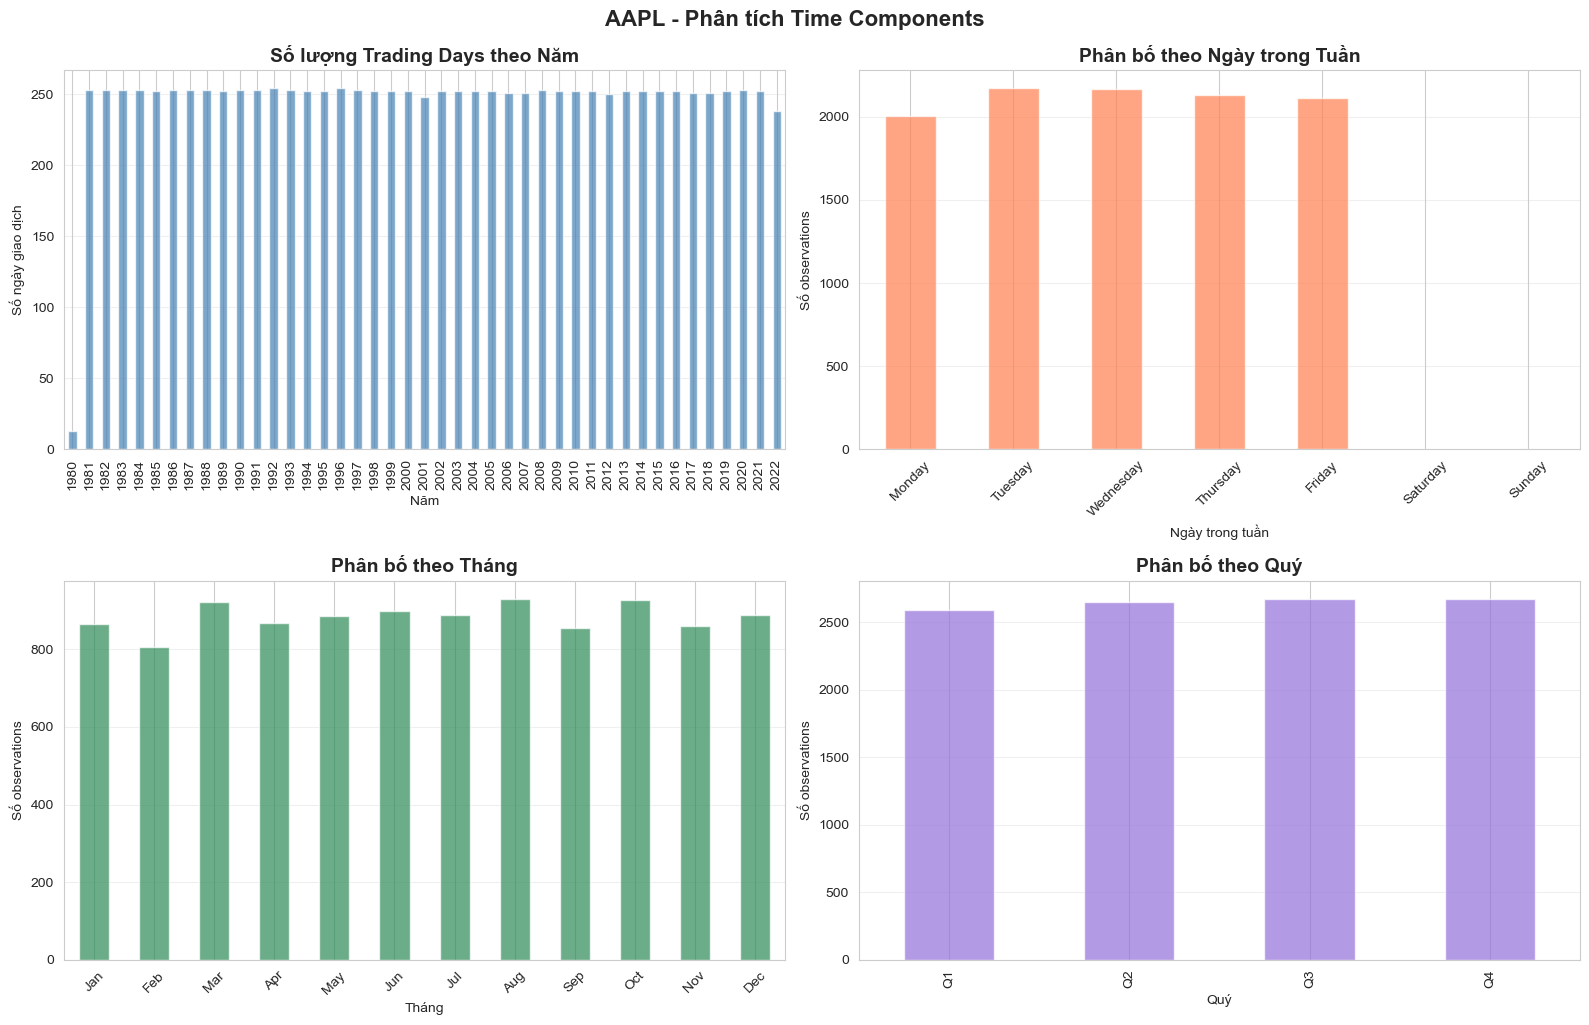


Nhận xét:
- Thị trường chứng khoán chỉ giao dịch từ Thứ Hai đến Thứ Sáu
- Mỗi năm thường có khoảng 252 ngày giao dịch (trừ cuối tuần và ngày lễ)
- Phân bố tương đối đồng đều theo tháng và quý


In [7]:
# Visualization 1: Phân bố dữ liệu theo năm
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Số lượng observations theo năm
year_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Số lượng Trading Days theo Năm', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Năm')
axes[0, 0].set_ylabel('Số ngày giao dịch')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Phân bố theo ngày trong tuần
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts_ordered = aapl_df['DayName'].value_counts().reindex(day_order, fill_value=0)
day_counts_ordered.plot(kind='bar', ax=axes[0, 1], color='coral', alpha=0.7)
axes[0, 1].set_title('Phân bố theo Ngày trong Tuần', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Ngày trong tuần')
axes[0, 1].set_ylabel('Số observations')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Phân bố theo tháng
month_counts = aapl_df['Month'].value_counts().sort_index()
month_counts.plot(kind='bar', ax=axes[1, 0], color='seagreen', alpha=0.7)
axes[1, 0].set_title('Phân bố theo Tháng', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Tháng')
axes[1, 0].set_ylabel('Số observations')
axes[1, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Phân bố theo quý
quarter_counts = aapl_df['Quarter'].value_counts().sort_index()
quarter_counts.plot(kind='bar', ax=axes[1, 1], color='mediumpurple', alpha=0.7)
axes[1, 1].set_title('Phân bố theo Quý', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Quý')
axes[1, 1].set_ylabel('Số observations')
axes[1, 1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('AAPL - Phân tích Time Components', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\nNhận xét:")
print("- Thị trường chứng khoán chỉ giao dịch từ Thứ Hai đến Thứ Sáu")
print("- Mỗi năm thường có khoảng 252 ngày giao dịch (trừ cuối tuần và ngày lễ)")
print("- Phân bố tương đối đồng đều theo tháng và quý")


---

# 4. Handling Time Gaps (Xử lý Khoảng Trống Thời Gian)

### Mục đích:
- Xác định các khoảng trống (missing timestamps) trong chuỗi thời gian
- So sánh các phương pháp fill gaps: Forward Fill, Backward Fill, Interpolation
- Đánh giá hiệu quả của từng phương pháp

### Lý thuyết:

**1. Forward Fill (ffill)**: Điền giá trị từ observation trước đó
- Ưu điểm: Đơn giản, giữ nguyên giá trị thực tế
- Nhược điểm: Có thể tạo ra "bậc thang" trong dữ liệu

**2. Backward Fill (bfill)**: Điền giá trị từ observation sau
- Ưu điểm: Đơn giản, hữu ích khi muốn "nhìn về tương lai"
- Nhược điểm: Không phù hợp với time  series thực tế (leak information)

**3. Linear Interpolation**: Nội suy tuyến tính giữa 2 điểm
- Ưu điểm: Smooth, phù hợp với dữ liệu có xu hướng tuyến tính
- Nhược điểm: Không nắm bắt được pattern phi tuyến

**4. Polynomial Interpolation**: Nội suy đa thức bậc cao
- Ưu điểm: Nắm bắt được pattern phức tạp hơn
- Nhược điểm: Có thể overfitting, tạo ra giá trị không hợp lý

**5. Spline Interpolation**: Nội suy sử dụng spline functions
- Ưu điểm: Smooth, linh hoạt, ít overfitting hơn polynomial
- Nhược điểm: Phức tạp hơn, cần nhiều tính toán


In [8]:
# Bước 1: Xác định missing timestamps
print("PHÂN TÍCH TIME GAPS")
print("="*70)

# Tạo range đầy đủ của tất cả các ngày (bao gồm cả cuối tuần)
date_range_all = pd.date_range(start=aapl_df.index.min(), 
                                end=aapl_df.index.max(), 
                                freq='D')

# Tìm missing dates
missing_dates = date_range_all.difference(aapl_df.index)

print(f"Tổng số ngày trong khoảng thời gian: {len(date_range_all):,}")
print(f"Số ngày có dữ liệu: {len(aapl_df):,}")
print(f"Số ngày bị thiếu: {len(missing_dates):,}")
print(f"Tỷ lệ missing: {len(missing_dates)/len(date_range_all)*100:.2f}%")

# Phân tích missing dates theo ngày trong tuần
print("\nPhân bố missing dates theo ngày trong tuần:")
missing_daynames = pd.Series(missing_dates).dt.day_name().value_counts()
print(missing_daynames)

print("\nNhận xét:")
print("- Phần lớn missing dates là cuối tuần (Saturday & Sunday)")
print("- Còn lại là các ngày lễ của thị trường chứng khoán Mỹ")


PHÂN TÍCH TIME GAPS
Tổng số ngày trong khoảng thời gian: 15,341
Số ngày có dữ liệu: 10,590
Số ngày bị thiếu: 4,751
Tỷ lệ missing: 30.97%

Phân bố missing dates theo ngày trong tuần:
Saturday     2192
Sunday       2192
Monday        188
Friday         77
Thursday       61
Wednesday      21
Tuesday        20
Name: count, dtype: int64

Nhận xét:
- Phần lớn missing dates là cuối tuần (Saturday & Sunday)
- Còn lại là các ngày lễ của thị trường chứng khoán Mỹ


In [9]:
# Bước 2: Tạo DataFrame với full date range để có gaps
print("Tạo DataFrame với đầy đủ date range...")

# Chỉ lấy cột Close để demo rõ ràng hơn
aapl_close = aapl_df[['Close']].copy()

# Reindex với tất cả các ngày
aapl_with_gaps = aapl_close.reindex(date_range_all)

print(f"Đã tạo DataFrame với {len(aapl_with_gaps):,} rows")
print(f"Số giá trị missing: {aapl_with_gaps['Close'].isna().sum():,}")
print(f"\nMẫu dữ liệu với gaps (cuối tuần):")
# Hiển thị một tuần để thấy gaps
sample_week = aapl_with_gaps['2022-01-03':'2022-01-09']
display(sample_week)


Tạo DataFrame với đầy đủ date range...
Đã tạo DataFrame với 15,341 rows
Số giá trị missing: 4,751

Mẫu dữ liệu với gaps (cuối tuần):


,Close
2022-01-03,182.009995
2022-01-04,179.699997
2022-01-05,174.919998
2022-01-06,172.000000
2022-01-07,172.169998
2022-01-08,NaN
2022-01-09,NaN


In [10]:
# Bước 3: Áp dụng các phương pháp fill gaps
print("Áp dụng các phương pháp điền gaps...\n")

# Method 1: Forward Fill
aapl_ffill = aapl_with_gaps.copy()
aapl_ffill['Close_ffill'] = aapl_ffill['Close'].fillna(method='ffill')
print("Forward Fill complete")

# Method 2: Backward Fill
aapl_bfill = aapl_with_gaps.copy()
aapl_bfill['Close_bfill'] = aapl_bfill['Close'].fillna(method='bfill')
print("Backward Fill complete")

# Method 3: Linear Interpolation
aapl_linear = aapl_with_gaps.copy()
aapl_linear['Close_linear'] = aapl_linear['Close'].interpolate(method='linear')
print("Linear Interpolation complete")

# Method 4: Polynomial Interpolation (bậc 2)
aapl_poly = aapl_with_gaps.copy()
aapl_poly['Close_poly'] = aapl_poly['Close'].interpolate(method='polynomial', order=2)
print("Polynomial Interpolation complete")

# Method 5: Spline Interpolation
aapl_spline = aapl_with_gaps.copy()
aapl_spline['Close_spline'] = aapl_spline['Close'].interpolate(method='spline', order=2)
print("Spline Interpolation complete")

# Kết hợp tất cả vào một DataFrame để so sánh
comparison_df = pd.DataFrame({
    'Original': aapl_with_gaps['Close'],
    'Forward_Fill': aapl_ffill['Close_ffill'],
    'Backward_Fill': aapl_bfill['Close_bfill'],
    'Linear': aapl_linear['Close_linear'],
    'Polynomial': aapl_poly['Close_poly'],
    'Spline': aapl_spline['Close_spline']
})

print("\nSo sánh các phương pháp trong một tuần:")
display(comparison_df['2022-01-03':'2022-01-11'].round(2))


Áp dụng các phương pháp điền gaps...

Forward Fill complete
Backward Fill complete
Linear Interpolation complete
Polynomial Interpolation complete
Spline Interpolation complete

So sánh các phương pháp trong một tuần:


,Original,Forward_Fill,Backward_Fill,Linear,Polynomial,Spline
2022-01-03,182.01,182.01,182.01,182.01,182.01,182.01
2022-01-04,179.70,179.70,179.70,179.70,179.70,179.70
2022-01-05,174.92,174.92,174.92,174.92,174.92,174.92
2022-01-06,172.00,172.00,172.00,172.00,172.00,172.00
2022-01-07,172.17,172.17,172.17,172.17,172.17,172.17
2022-01-08,NaN,172.17,172.19,172.18,171.92,174.53
2022-01-09,NaN,172.17,172.19,172.18,171.07,174.08
2022-01-10,172.19,172.19,172.19,172.19,172.19,172.19
2022-01-11,175.08,175.08,175.08,175.08,175.08,175.08


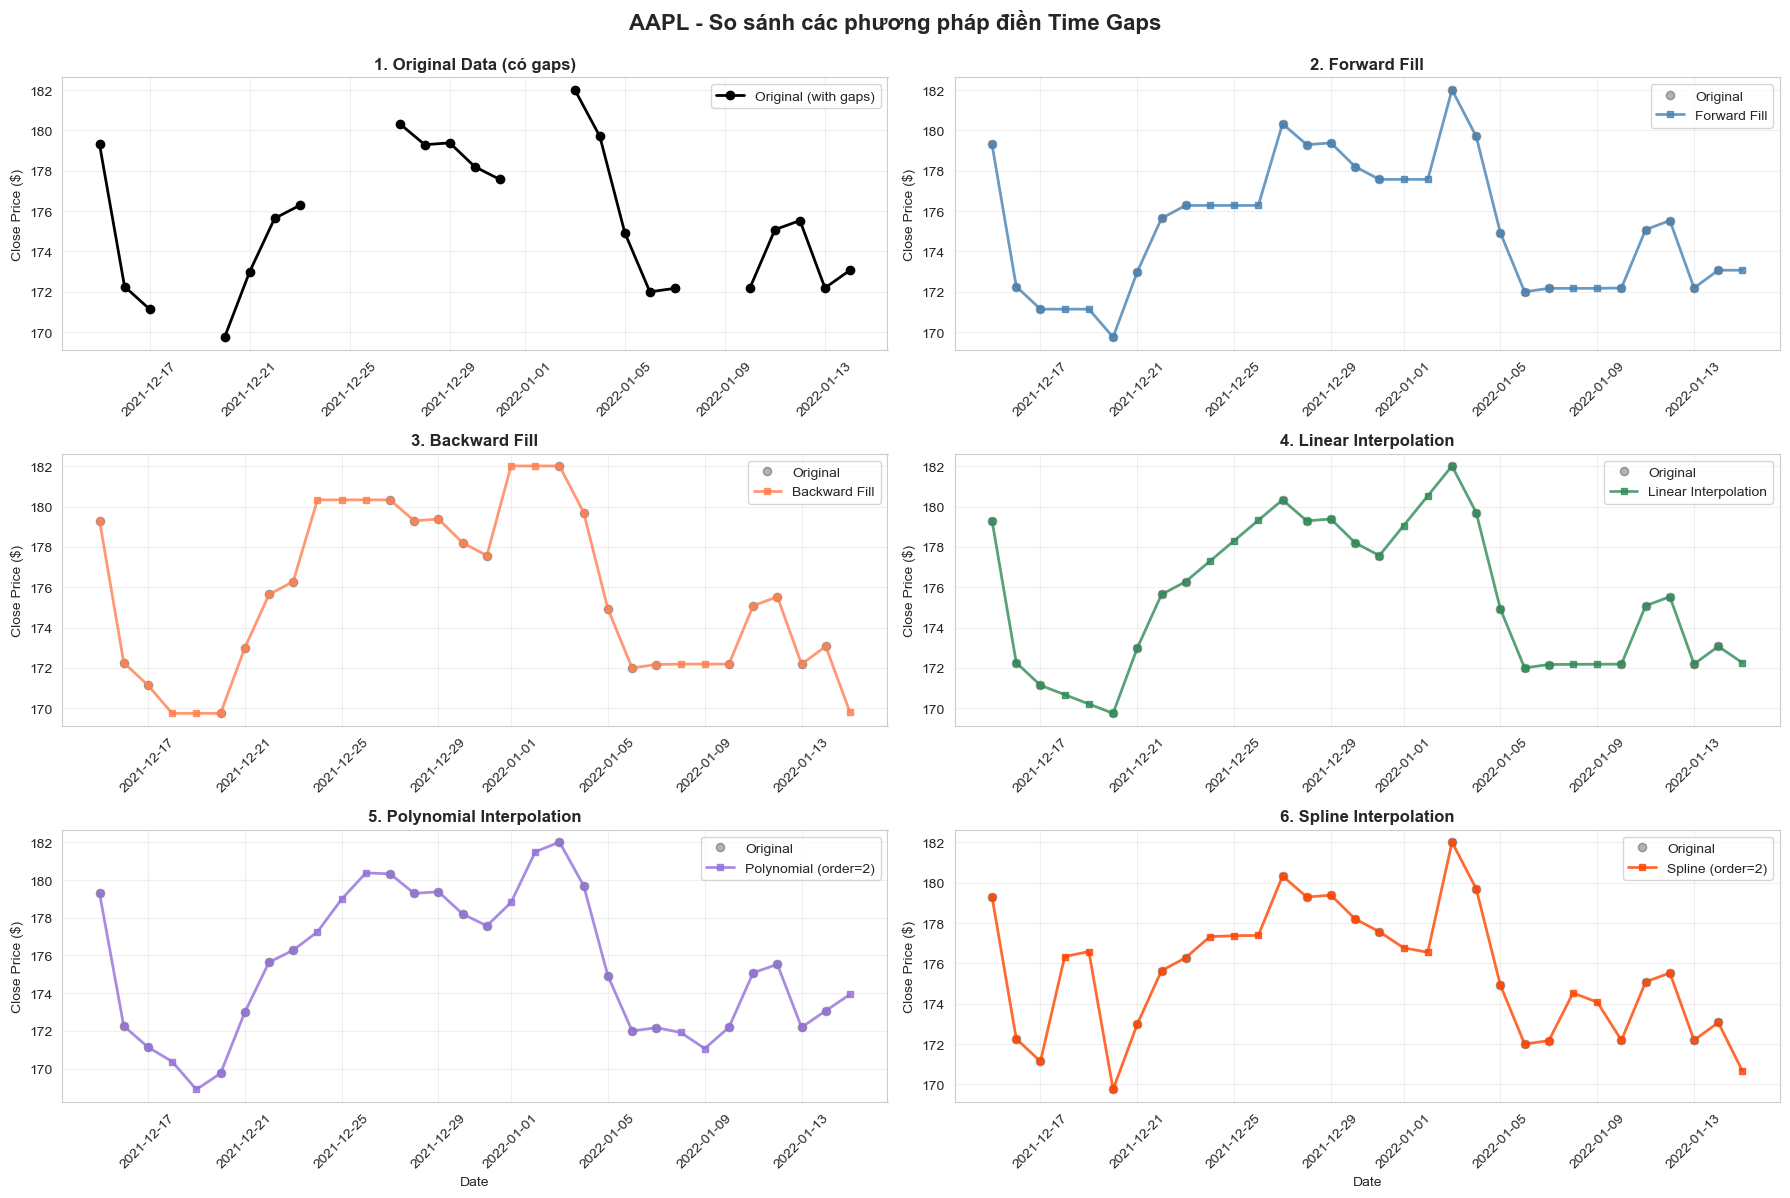

In [11]:
# Visualization: So sánh các phương pháp fill gaps
# Chọn một khoảng thời gian ngắn để dễ quan sát
start_date = '2021-12-15'
end_date = '2022-01-15'
plot_data = comparison_df[start_date:end_date]

fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('AAPL - So sánh các phương pháp điền Time Gaps', 
             fontsize=16, fontweight='bold', y=0.995)

# 1. Original with gaps
axes[0, 0].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='-', linewidth=2, markersize=6,
                color='black', label='Original (with gaps)')
axes[0, 0].set_title('1. Original Data (có gaps)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Close Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Forward Fill
axes[0, 1].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[0, 1].plot(plot_data.index, plot_data['Forward_Fill'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='steelblue', label='Forward Fill', alpha=0.8)
axes[0, 1].set_title('2. Forward Fill', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Close Price ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Backward Fill
axes[1, 0].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[1, 0].plot(plot_data.index, plot_data['Backward_Fill'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='coral', label='Backward Fill', alpha=0.8)
axes[1, 0].set_title('3. Backward Fill', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Close Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Linear Interpolation
axes[1, 1].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[1, 1].plot(plot_data.index, plot_data['Linear'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='seagreen', label='Linear Interpolation', alpha=0.8)
axes[1, 1].set_title('4. Linear Interpolation', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Close Price ($)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Polynomial Interpolation
axes[2, 0].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[2, 0].plot(plot_data.index, plot_data['Polynomial'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='mediumpurple', label='Polynomial (order=2)', alpha=0.8)
axes[2, 0].set_title('5. Polynomial Interpolation', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Date')
axes[2, 0].set_ylabel('Close Price ($)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].tick_params(axis='x', rotation=45)

# 6. Spline Interpolation
axes[2, 1].plot(plot_data.index, plot_data['Original'], 
                marker='o', linestyle='', markersize=6,
                color='black', alpha=0.3, label='Original')
axes[2, 1].plot(plot_data.index, plot_data['Spline'], 
                marker='s', linestyle='-', linewidth=2, markersize=4,
                color='orangered', label='Spline (order=2)', alpha=0.8)
axes[2, 1].set_title('6. Spline Interpolation', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Date')
axes[2, 1].set_ylabel('Close Price ($)')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# Đánh giá hiệu quả: So sánh với giá trị thực tế
# Để đánh giá, ta sẽ tạo gaps giả và so sánh

print("ĐÁNH GIÁ HIỆU QUẢ CÁC PHƯƠNG PHÁP")
print("="*70)

# Lấy dữ liệu không có gaps
aapl_complete = aapl_close.copy()

# Tạo gaps giả: xóa một số giá trị ngẫu nhiên
np.random.seed(42)
test_indices = np.random.choice(aapl_complete.index[100:200], size=20, replace=False)
aapl_test = aapl_complete.copy()
aapl_test.loc[test_indices, 'Close'] = np.nan

# Lưu giá trị thực
true_values = aapl_complete.loc[test_indices, 'Close']

# Áp dụng các phương pháp
methods = {
    'Forward Fill': aapl_test['Close'].fillna(method='ffill'),
    'Backward Fill': aapl_test['Close'].fillna(method='bfill'),
    'Linear': aapl_test['Close'].interpolate(method='linear'),
    'Polynomial': aapl_test['Close'].interpolate(method='polynomial', order=2),
    'Spline': aapl_test['Close'].interpolate(method='spline', order=2)
}

# Tính toán metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
for method_name, predictions in methods.items():
    pred_values = predictions.loc[test_indices]
    mae = mean_absolute_error(true_values, pred_values)
    rmse = np.sqrt(mean_squared_error(true_values, pred_values))
    mape = np.mean(np.abs((true_values - pred_values) / true_values)) * 100
    r2 = r2_score(true_values, pred_values)
    
    results.append({
        'Method': method_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')

print("\nKết quả đánh giá (sắp xếp theo RMSE - càng nhỏ càng tốt):")
display(results_df.round(4))

print("\nGiải thích metrics:")
print("- MAE (Mean Absolute Error): Sai số tuyệt đối trung bình")
print("- RMSE (Root Mean Square Error): Căn bậc hai của sai số bình phương trung bình")
print("- MAPE (Mean Absolute Percentage Error): Sai số phần trăm tuyệt đối trung bình")
print("- R² (R-squared): Hệ số xác định (1 = perfect fit, 0 = no correlation)")

ĐÁNH GIÁ HIỆU QUẢ CÁC PHƯƠNG PHÁP

Kết quả đánh giá (sắp xếp theo RMSE - càng nhỏ càng tốt):


,Method,MAE,RMSE,MAPE (%),R²
3,Polynomial,0.0022,0.0028,2.0079,0.9805
2,Linear,0.0022,0.0029,1.9936,0.9785
1,Backward Fill,0.0033,0.0039,2.9976,0.9613
0,Forward Fill,0.0030,0.0041,2.7547,0.9586
4,Spline,0.0606,0.0655,51.6454,-9.6325



Giải thích metrics:
- MAE (Mean Absolute Error): Sai số tuyệt đối trung bình
- RMSE (Root Mean Square Error): Căn bậc hai của sai số bình phương trung bình
- MAPE (Mean Absolute Percentage Error): Sai số phần trăm tuyệt đối trung bình
- R² (R-squared): Hệ số xác định (1 = perfect fit, 0 = no correlation)


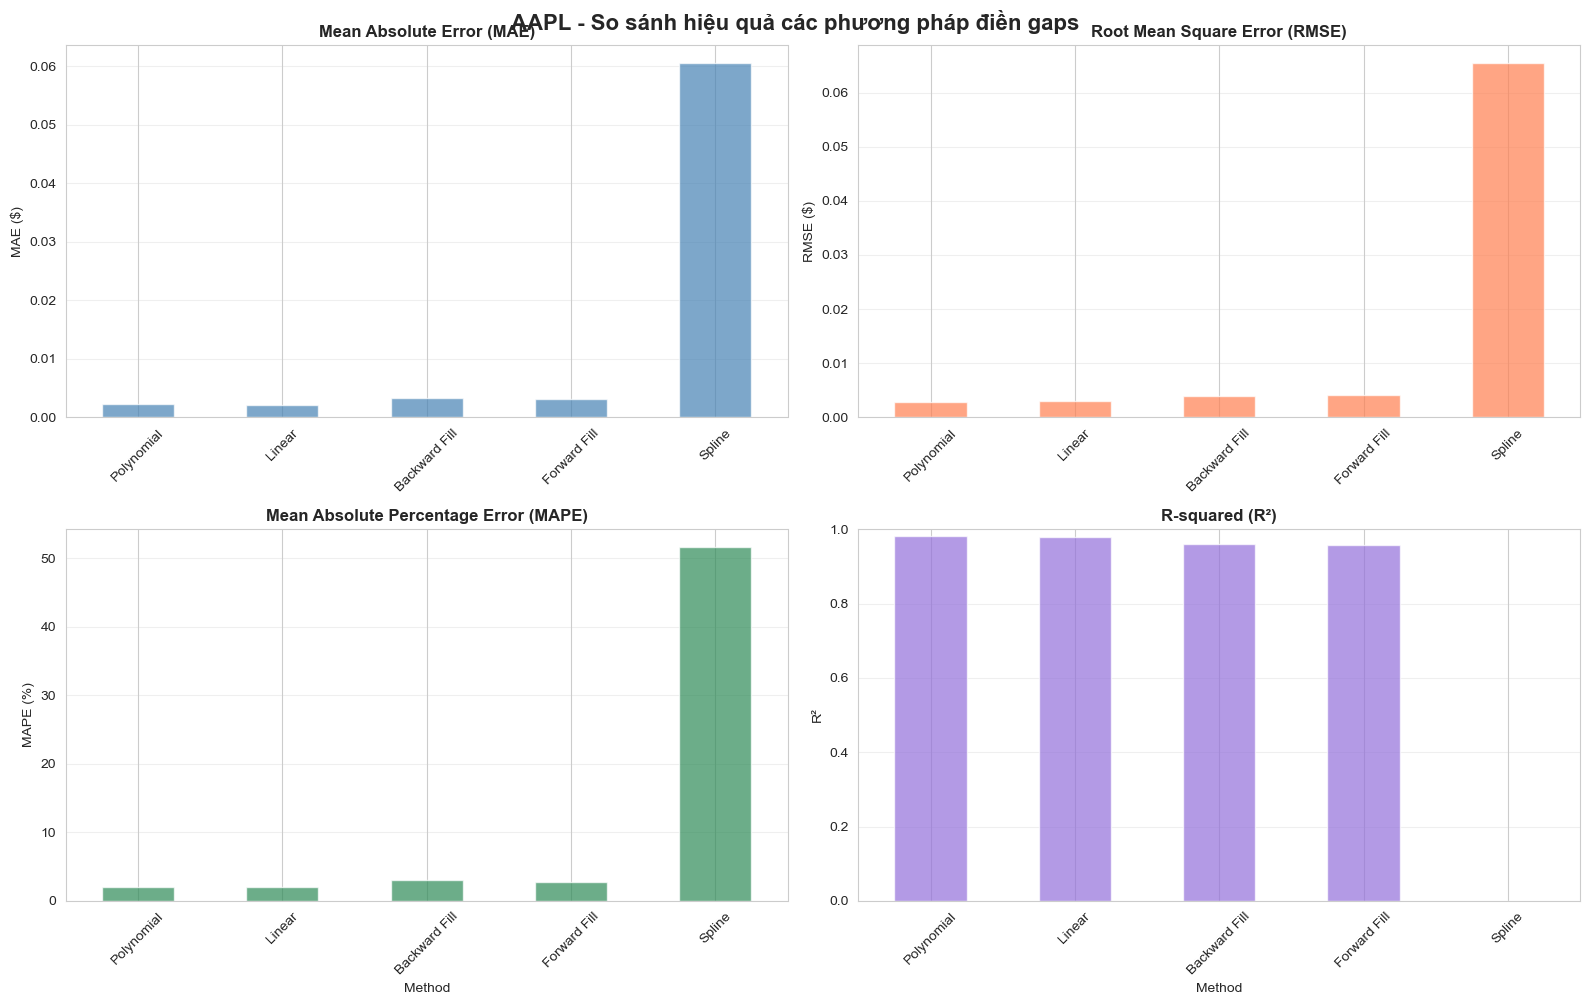

In [13]:
# Visualization: So sánh metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. MAE
results_df.plot(x='Method', y='MAE', kind='bar', ax=axes[0, 0], 
                color='steelblue', alpha=0.7, legend=False)
axes[0, 0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('MAE ($)')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. RMSE
results_df.plot(x='Method', y='RMSE', kind='bar', ax=axes[0, 1], 
                color='coral', alpha=0.7, legend=False)
axes[0, 1].set_title('Root Mean Square Error (RMSE)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('RMSE ($)')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. MAPE
results_df.plot(x='Method', y='MAPE (%)', kind='bar', ax=axes[1, 0], 
                color='seagreen', alpha=0.7, legend=False)
axes[1, 0].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('MAPE (%)')
axes[1, 0].set_xlabel('Method')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. R²
results_df.plot(x='Method', y='R²', kind='bar', ax=axes[1, 1], 
                color='mediumpurple', alpha=0.7, legend=False)
axes[1, 1].set_title('R-squared (R²)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_xlabel('Method')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('AAPL - So sánh hiệu quả các phương pháp điền gaps', 
             fontsize=16, fontweight='bold', y=1.00)
plt.show()

---

# 5. Extracting Time-Based Features (Trích xuất đặc trưng thời gian)

### Mục đích:
- Tạo ra các đặc trưng (features) mới từ dữ liệu thời gian để phục vụ cho machine learning
- Trích xuất các đặc trưng chu kỳ (cyclical features)
- Trích xuất các đặc trưng mùa vụ (seasonal features)
- Kiểm tra tính dừng (stationarity) của chuỗi thời gian

### Lý thuyết:
Mô hình Machine Learning thường không hiểu trực tiếp khái niệm thời gian. Chúng ta cần chuyển đổi thời gian thành các con số có ý nghĩa:
- **Time Components**: Year, Month, Day, Hour... (đã làm ở phần 3)
- **Cyclical Features**: Biến đổi features có tính chu kỳ (Month, DayOfWeek) thành cặp sin/cos để giữ tính liên tục (ví dụ: tháng 12 gần tháng 1)
- **Time Differences**: Khoảng thời gian từ một sự kiện quan trọng
- **Rolling Winndow Features**: (sẽ làm ở phần 6)
    
### Triển khai:
Chúng ta sẽ tiếp tục làm việc với dữ liệu AAPL đã xử lý.


Tạo Time-based Features...
Đã tạo xong các features bổ sung.

Xem mẫu dữ liệu với features mới:


,Month,Month_sin,IsWeekend,IsQuarterEnd,DaysSinceStart
Date,,,,,
1980-12-12,12,-2.449294e-16,0,0,0
1980-12-15,12,-2.449294e-16,0,0,3
1980-12-16,12,-2.449294e-16,0,0,4
1980-12-17,12,-2.449294e-16,0,0,5
1980-12-18,12,-2.449294e-16,0,0,6
1980-12-19,12,-2.449294e-16,0,0,7
1980-12-22,12,-2.449294e-16,0,0,10
1980-12-23,12,-2.449294e-16,0,0,11
1980-12-24,12,-2.449294e-16,0,0,12


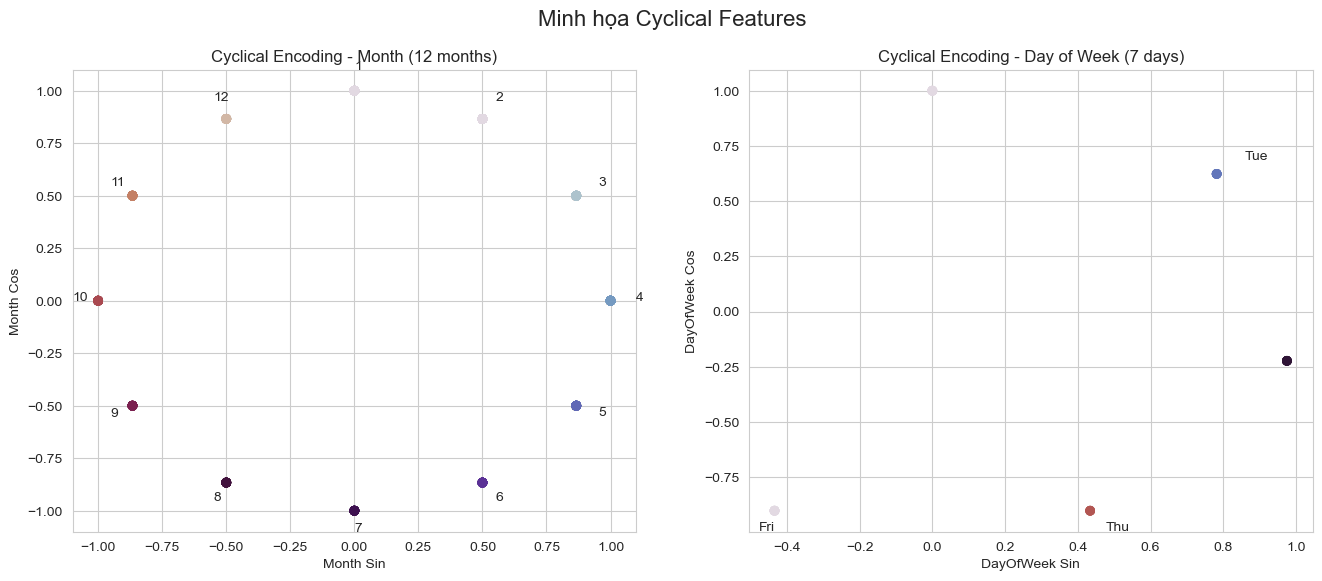


Giải thích:
Việc sử dụng sin/cos giúp mô hình hiểu được tính chu kỳ của thời gian.
Feature mới 'DaysSinceStart' giúp mô hình nắm bắt xu hướng dài hạn (trend) theo thời gian tuyến tính.


In [14]:
# 1. Cyclical Encoding cho Month và DayOfWeek & Indicator Variables
print("Tạo Time-based Features...")

# Tạo copy để không ảnh hưởng dữ liệu gốc
aapl_features = aapl_df.copy()

# --- A. Feature Encoding ---
# Month (1-12)
aapl_features['Month_sin'] = np.sin(2 * np.pi * aapl_features['Month'] / 12)
aapl_features['Month_cos'] = np.cos(2 * np.pi * aapl_features['Month'] / 12)

# DayOfWeek (0-6)
aapl_features['DayOfWeek_sin'] = np.sin(2 * np.pi * aapl_features['DayOfWeek'] / 7)
aapl_features['DayOfWeek_cos'] = np.cos(2 * np.pi * aapl_features['DayOfWeek'] / 7)

# Quarter (1-4)
aapl_features['Quarter_sin'] = np.sin(2 * np.pi * aapl_features['Quarter'] / 4)
aapl_features['Quarter_cos'] = np.cos(2 * np.pi * aapl_features['Quarter'] / 4)

# --- B. Indicator Variables (New) ---
# IsWeekend: 1 nếu là T7/CN, 0 ngược lại (mặc dù dữ liệu chứng khoán thường ko có cuối tuần, nhưng đây là yêu cầu)
aapl_features['IsWeekend'] = aapl_features['DayOfWeek'].isin([5, 6]).astype(int)

# IsQuarterEnd: 1 nếu là ngày cuối quý
aapl_features['IsQuarterEnd'] = aapl_features.index.is_quarter_end.astype(int)

# --- C. Time Elapsed (New) ---
# Số ngày trôi qua kể từ ngày bắt đầu trong dataset
min_date = aapl_features.index.min()
aapl_features['DaysSinceStart'] = (aapl_features.index - min_date).days

print("Đã tạo xong các features bổ sung.")
print("\nXem mẫu dữ liệu với features mới:")
display(aapl_features[['Month', 'Month_sin', 'IsWeekend', 'IsQuarterEnd', 'DaysSinceStart']].head(12))

# Visualization Cyclical Features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Month Cyclical
axes[0].scatter(aapl_features['Month_sin'][:365], aapl_features['Month_cos'][:365], c=aapl_features['Month'][:365], cmap='twilight')
axes[0].set_title('Cyclical Encoding - Month (12 months)')
axes[0].set_xlabel('Month Sin')
axes[0].set_ylabel('Month Cos')
axes[0].grid(True)
for i, txt in enumerate(range(1, 13)):
    angle = 2 * np.pi * i / 12
    # Simple approx for label placement
    axes[0].annotate(txt, (np.sin(angle)*1.1, np.cos(angle)*1.1))

# DayOfWeek Cyclical
axes[1].scatter(aapl_features['DayOfWeek_sin'][:30], aapl_features['DayOfWeek_cos'][:30], c=aapl_features['DayOfWeek'][:30], cmap='twilight')
axes[1].set_title('Cyclical Encoding - Day of Week (7 days)')
axes[1].set_xlabel('DayOfWeek Sin')
axes[1].set_ylabel('DayOfWeek Cos')
axes[1].grid(True)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for i, txt in enumerate(days):
    angle = 2 * np.pi * i / 7
    axes[1].annotate(txt, (np.sin(angle)*1.1, np.cos(angle)*1.1))

plt.suptitle('Minh họa Cyclical Features', fontsize=16)
plt.show()

print("\nGiải thích:")
print("Việc sử dụng sin/cos giúp mô hình hiểu được tính chu kỳ của thời gian.")
print("Feature mới 'DaysSinceStart' giúp mô hình nắm bắt xu hướng dài hạn (trend) theo thời gian tuyến tính.")


Kiểm tra tính dừng cho AAPL Close Price:
----------------------------------------
Test Statistic                     2.304848
p-value                            0.998958
#Lags Used                        39.000000
Number of Observations Used    10550.000000
Critical Value (1%)               -3.430970
Critical Value (5%)               -2.861814
Critical Value (10%)              -2.566916
dtype: float64
-> p-value (0.9990) >= 0.05: Chấp nhận H0.
   Kết luận: Chuỗi số liệu KHÔNG có tính dừng (Non-Stationary).

Kiểm tra tính dừng cho AAPL Differenced Close Price:
----------------------------------------
Test Statistic                -1.780240e+01
p-value                        3.213956e-30
#Lags Used                     3.900000e+01
Number of Observations Used    1.054900e+04
Critical Value (1%)           -3.430970e+00
Critical Value (5%)           -2.861814e+00
Critical Value (10%)          -2.566916e+00
dtype: float64
-> p-value (0.0000) < 0.05: Bác bỏ H0.
   Kết luận: Chuỗi số liệu CÓ 

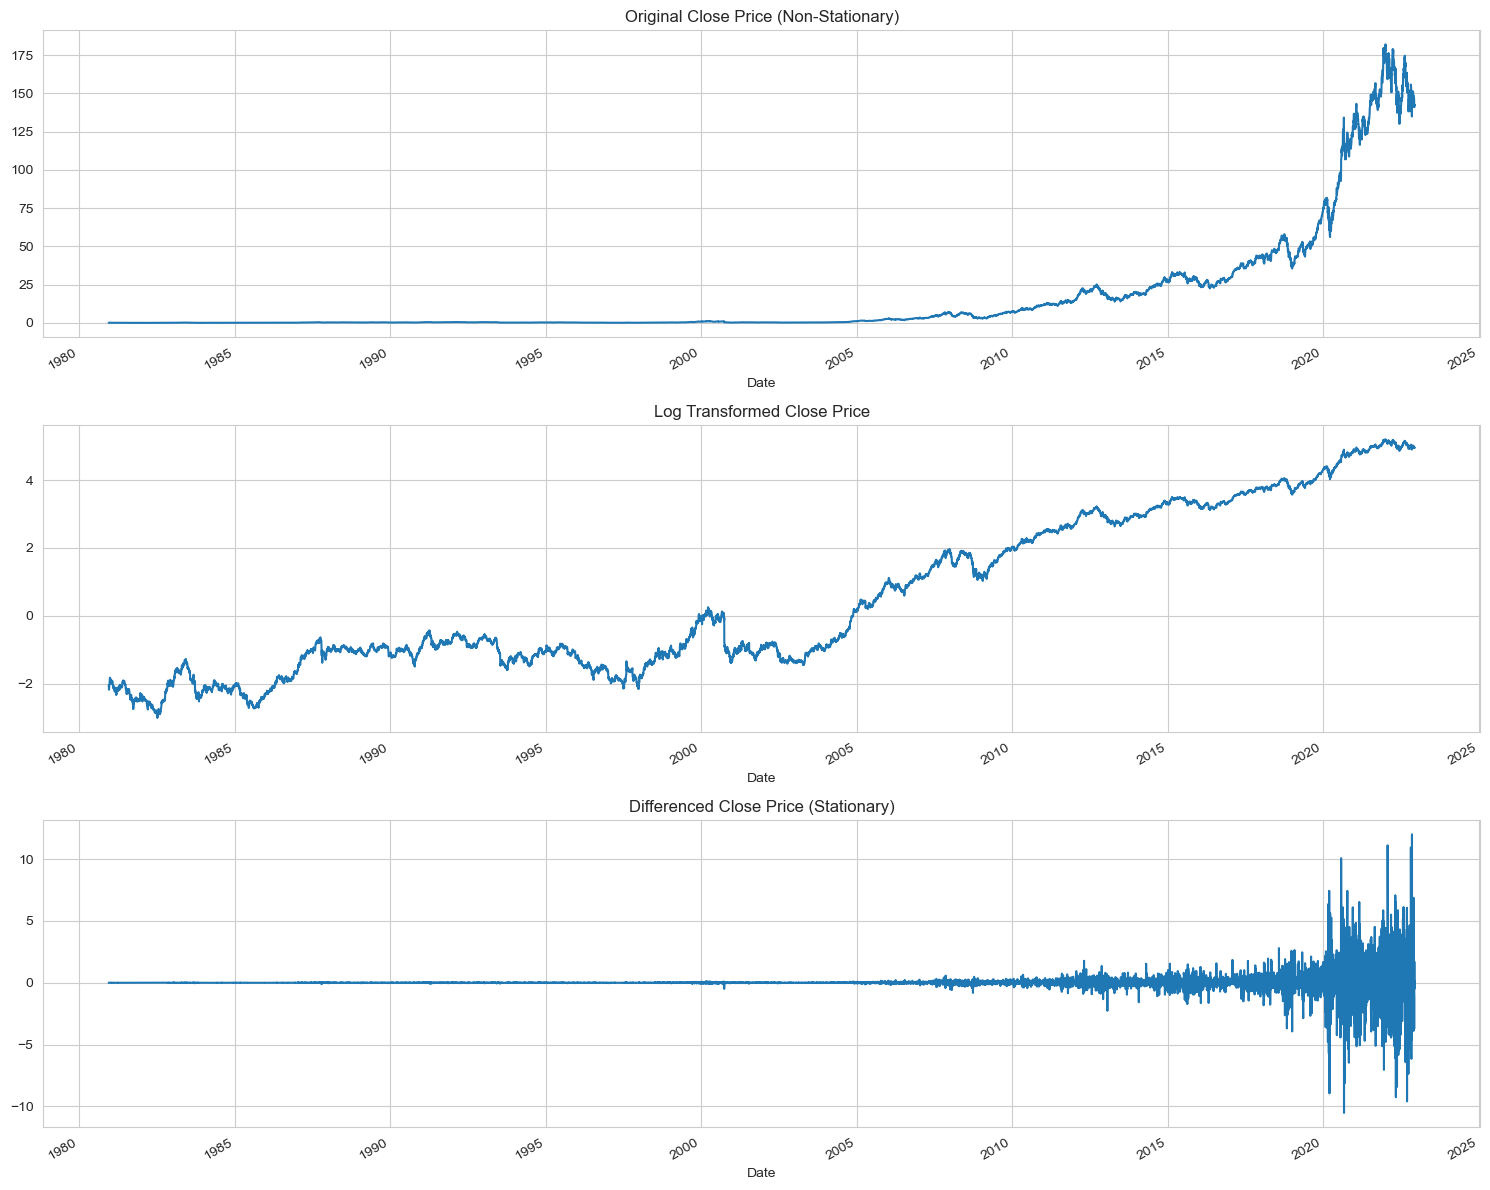

In [15]:
# 2. Kiểm tra tính dừng (Stationarity)
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries, name="Series"):
    print(f"\nKiểm tra tính dừng cho {name}:")
    print("-" * 40)
    
    # Perform Dickey-Fuller test:
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
        
    print(dfoutput)
    
    # Kết luận
    if dfoutput['p-value'] < 0.05:
        print(f"-> p-value ({dfoutput['p-value']:.4f}) < 0.05: Bác bỏ H0.")
        print("   Kết luận: Chuỗi số liệu CÓ tính dừng (Stationary).")
    else:
        print(f"-> p-value ({dfoutput['p-value']:.4f}) >= 0.05: Chấp nhận H0.")
        print("   Kết luận: Chuỗi số liệu KHÔNG có tính dừng (Non-Stationary).")

# Kiểm tra với giá Close
check_stationarity(aapl_features['Close'], "AAPL Close Price")

# Log transformation để ổn định phương sai
aapl_features['Log_Close'] = np.log(aapl_features['Close'])

# Differencing để loại bỏ xu hướng (trend)
aapl_features['Diff_Close'] = aapl_features['Close'].diff()
aapl_features['Log_Diff_Close'] = aapl_features['Log_Close'].diff()

# Kiểm tra lại với chuỗi đã differencing
check_stationarity(aapl_features['Diff_Close'], "AAPL Differenced Close Price")

# Visualization Stationarity
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
aapl_features['Close'].plot(ax=axes[0], title='Original Close Price (Non-Stationary)')
aapl_features['Log_Close'].plot(ax=axes[1], title='Log Transformed Close Price')
aapl_features['Diff_Close'].plot(ax=axes[2], title='Differenced Close Price (Stationary)')
plt.tight_layout()
plt.show()


---

# 6. Resampling Time Series (Lấy mẫu lại dữ liệu)

### Mục đích:
- Thay đổi tần suất của dữ liệu (ví dụ: từ ngày sang tuần, tháng, năm)
- Downsampling: Giảm tần suất (Ngày -> Tháng) để tổng hợp dữ liệu
- Upsampling: Tăng tần suất (Tháng -> Ngày) để chi tiết hóa dữ liệu
- Làm mượt dữ liệu (Smoothing) để giảm nhiễu

### Giải thích:
Pandas cung cấp hàm `resample()` hoạt động tương tự như `groupby()` nhưng chuyên biệt cho index thời gian.
- **Aggregation**: mean(), sum(), min(), max(), first(), last()...
- **OHLC**: Open-High-Low-Close resampling thường dùng trong tài chính


Thực hiện Downsampling AAPL Data...
Dữ liệu gốc (Daily): 10590 dòng
Dữ liệu Monthly: 505 dòng
Dữ liệu Yearly: 43 dòng

Dữ liệu tổng hợp theo Tháng:


,Open,High,Low,Close,Volume
Date,,,,,
1980-12-31,0.128348,0.161272,0.112723,0.152344,1344851200
1981-01-31,0.154018,0.155134,0.126116,0.126116,608988800
1981-02-28,0.119420,0.128906,0.106027,0.118304,321619200
1981-03-31,0.118862,0.120536,0.096540,0.109375,700716800
1981-04-30,0.108817,0.131138,0.108259,0.126674,536928000


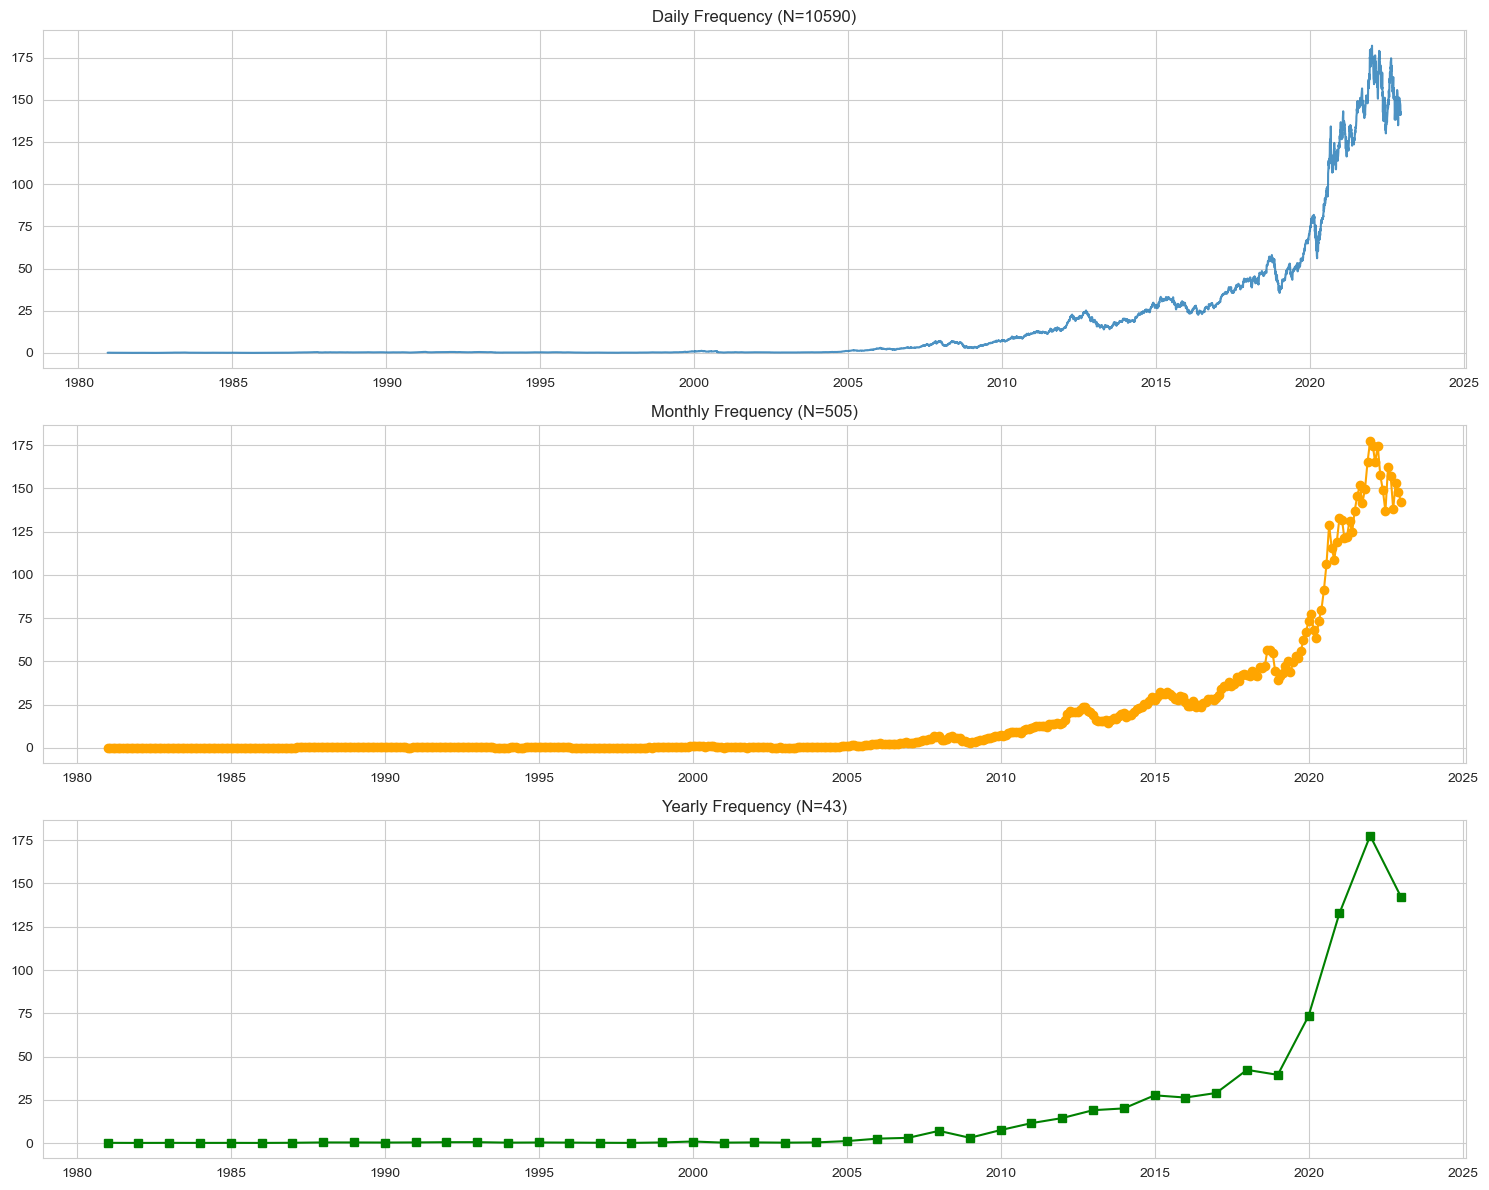

In [16]:
# 1. Downsampling: Tổng hợp dữ liệu theo Tháng và Năm
print("Thực hiện Downsampling AAPL Data...")

# Resample theo Tháng (M=Month End)
# Tính trung bình cho giá và tổng cho volume
monthly_aapl = aapl_df.resample('M').agg({
    'Open': 'first',      # Giá mở cửa đầu tháng
    'High': 'max',        # Giá cao nhất trong tháng
    'Low': 'min',         # Giá thấp nhất trong tháng
    'Close': 'last',      # Giá đóng cửa cuối tháng
    'Volume': 'sum'       # Tổng khối lượng giao dịch cả tháng
})

# Resample theo Năm (Y=Year End)
yearly_aapl = aapl_df.resample('Y').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})

print(f"Dữ liệu gốc (Daily): {len(aapl_df)} dòng")
print(f"Dữ liệu Monthly: {len(monthly_aapl)} dòng")
print(f"Dữ liệu Yearly: {len(yearly_aapl)} dòng")

# Hiển thị mẫu
print("\nDữ liệu tổng hợp theo Tháng:")
display(monthly_aapl.head())

# Visualization so sánh frequencies
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Daily
axes[0].plot(aapl_df.index, aapl_df['Close'], alpha=0.8)
axes[0].set_title(f'Daily Frequency (N={len(aapl_df)})')

# Monthly
axes[1].plot(monthly_aapl.index, monthly_aapl['Close'], marker='o', color='orange')
axes[1].set_title(f'Monthly Frequency (N={len(monthly_aapl)})')

# Yearly
axes[2].plot(yearly_aapl.index, yearly_aapl['Close'], marker='s', color='green')
axes[2].set_title(f'Yearly Frequency (N={len(yearly_aapl)})')

plt.tight_layout()
plt.show()


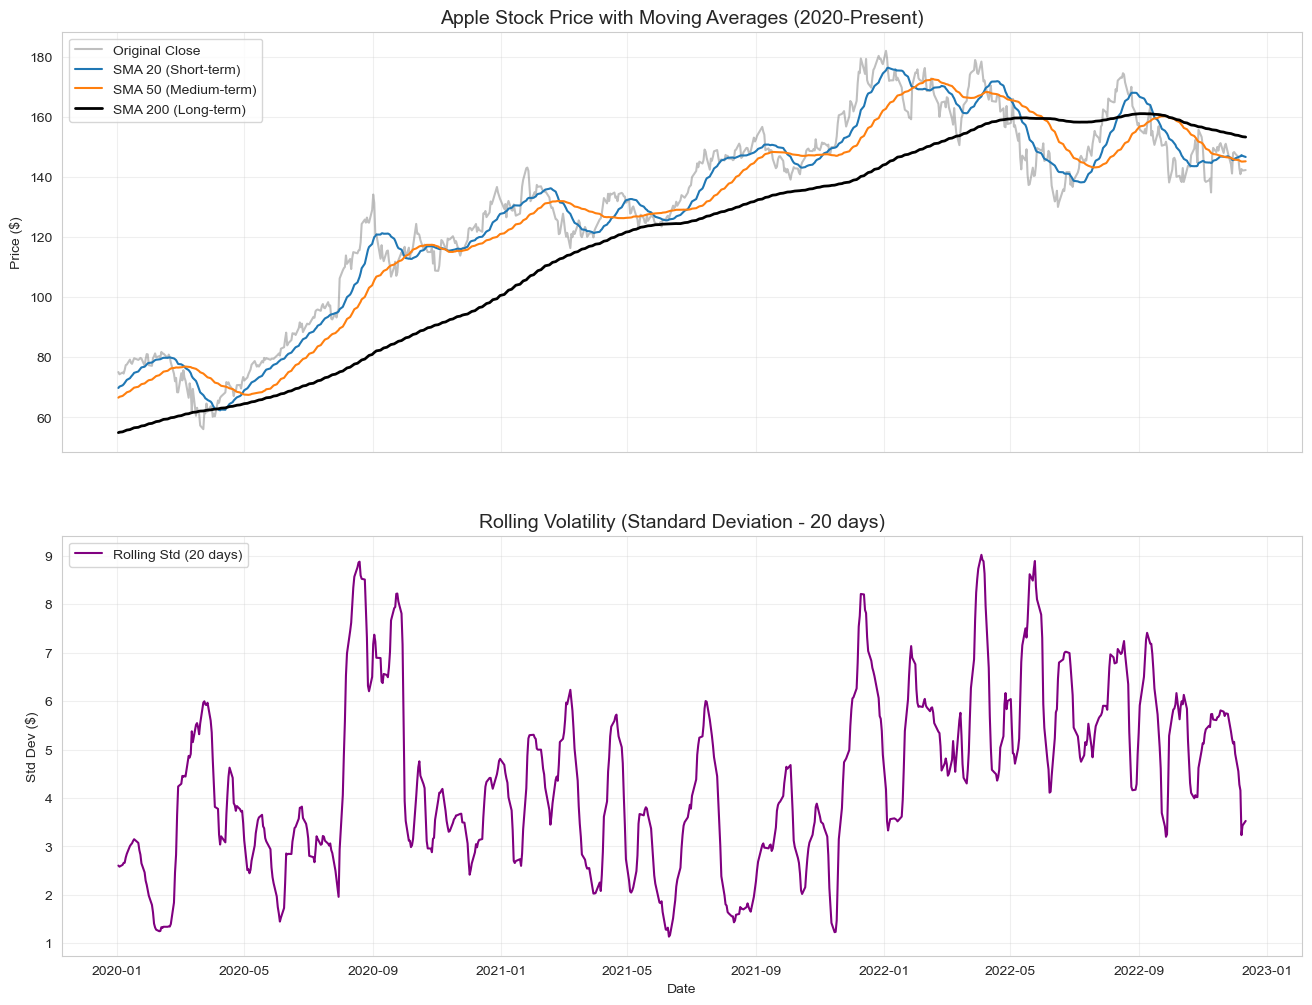

Nhận xét:
- SMA 20 bám sát giá rất tốt nhưng vẫn còn nhiều biến động.
- SMA 200 rất mượt, thể hiện xu hướng dài hạn.
- Rolling Std tăng cao trong những giai đoạn giá biến động mạnh (ví dụ đầu năm 2020 do Covid-19).
- Điểm giao cắt giữa SMA ngắn hạn và SMA dài hạn (Golden Cross / Death Cross) thường được dùng làm tín hiệu giao dịch.


In [17]:
# 2. Rolling Windows (Moving Average & Rolling Std)
# Đây là kỹ thuật Smoothing phổ biến và đo lường biến động (Volatility)

# A. Tính Rolling Mean (Simple Moving Average - SMA)
# Window = 20 ngày (~1 tháng giao dịch)
aapl_df['SMA_20'] = aapl_df['Close'].rolling(window=20).mean()

# Window = 50 ngày (~1 quý)
aapl_df['SMA_50'] = aapl_df['Close'].rolling(window=50).mean()

# Window = 200 ngày (~1 năm)
aapl_df['SMA_200'] = aapl_df['Close'].rolling(window=200).mean()

# B. Tính Rolling Standard Deviation (New)
# Đo lường sự biến động (volatility) trong khoảng thời gian 20 ngày (Bollinger Bands component)
aapl_df['Rol_Std_20'] = aapl_df['Close'].rolling(window=20).std()

# Visualization Rolling Means & Std
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Plot 1: Price & SMA
# Lấy dữ liệu 2 năm gần nhất để nhìn rõ hơn
subset = aapl_df.loc['2020-01-01':]

ax1.plot(subset.index, subset['Close'], label='Original Close', alpha=0.5, color='gray')
ax1.plot(subset.index, subset['SMA_20'], label='SMA 20 (Short-term)', linewidth=1.5)
ax1.plot(subset.index, subset['SMA_50'], label='SMA 50 (Medium-term)', linewidth=1.5)
ax1.plot(subset.index, subset['SMA_200'], label='SMA 200 (Long-term)', linewidth=2, color='black')

ax1.set_title('Apple Stock Price with Moving Averages (2020-Present)', fontsize=14)
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Rolling Standard Deviation (Volatility)
ax2.plot(subset.index, subset['Rol_Std_20'], label='Rolling Std (20 days)', color='purple', linewidth=1.5)
ax2.set_title('Rolling Volatility (Standard Deviation - 20 days)', fontsize=14)
ax2.set_xlabel('Date')
ax2.set_ylabel('Std Dev ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.show()

print("Nhận xét:")
print("- SMA 20 bám sát giá rất tốt nhưng vẫn còn nhiều biến động.")
print("- SMA 200 rất mượt, thể hiện xu hướng dài hạn.")
print("- Rolling Std tăng cao trong những giai đoạn giá biến động mạnh (ví dụ đầu năm 2020 do Covid-19).")
print("- Điểm giao cắt giữa SMA ngắn hạn và SMA dài hạn (Golden Cross / Death Cross) thường được dùng làm tín hiệu giao dịch.")

---

# 7. Lag Features & Autocorrelation (Đặc trưng trễ & Tự tương quan)

### Mục đích:
- **Lag Features**: Sử dụng giá trị quá khứ để dự báo tương lai (Past Predicts Future)
- **Autocorrelation (ACF)**: Đo lường mức độ tương quan giữa chuỗi số liệu và chính nó ở quá khứ
- **Partial Autocorrelation (PACF)**: Tương quan riêng phần sau khi loại bỏ ảnh hưởng của các lags trung gian

### Giải thích:
Trong Time Series Forecasting (ví dụ LSTM, ARIMA), việc sử dụng giá trị quá khứ làm input là kỹ thuật cơ bản nhất.
- Lag 1: Giá hôm qua
- Lag 7: Giá tuần trước
- Lag 365: Giá năm ngoái


Tạo Lag Features cho AAPL...

Mẫu dữ liệu với Lag Features:


,Close,Lag_1,Lag_2,Lag_3,Lag_20
Date,,,,,
1980-12-12,0.128348,NaN,NaN,NaN,NaN
1980-12-15,0.121652,0.128348,NaN,NaN,NaN
1980-12-16,0.112723,0.121652,0.128348,NaN,NaN
1980-12-17,0.115513,0.112723,0.121652,0.128348,NaN
1980-12-18,0.118862,0.115513,0.112723,0.121652,NaN
1980-12-19,0.126116,0.118862,0.115513,0.112723,NaN
1980-12-22,0.132254,0.126116,0.118862,0.115513,NaN
1980-12-23,0.137835,0.132254,0.126116,0.118862,NaN
1980-12-24,0.145089,0.137835,0.132254,0.126116,NaN


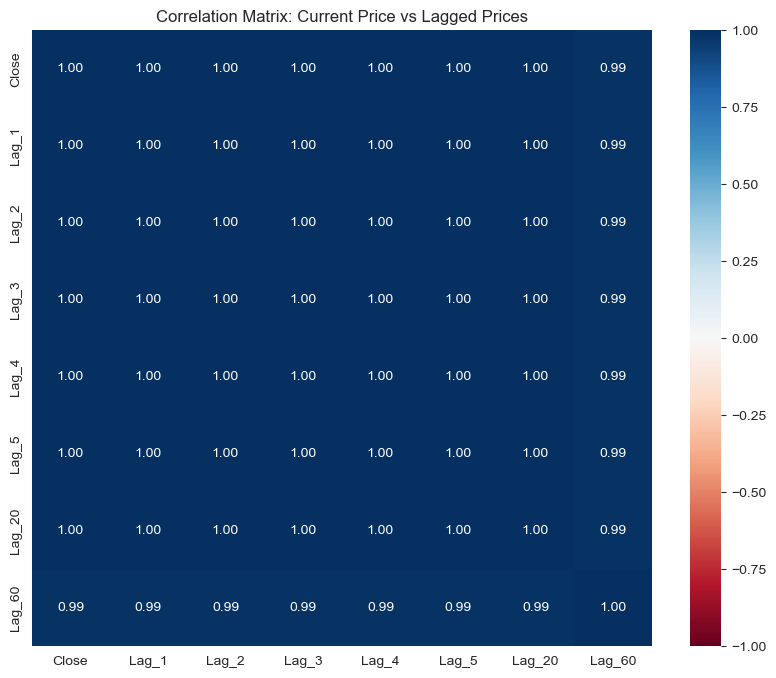


Nhận xét:
- Correlation giữa 'Close' và các 'Lag' gần (1,2,3) thường rất cao (gần 1.0).
- Điều này cho thấy giá cổ phiếu có tính tự tương quan mạnh (giá hôm nay phụ thuộc nhiều vào giá hôm qua).


In [18]:
# 1. Tạo Lag Features
print("Tạo Lag Features cho AAPL...")

# Lag 1 đến Lag 5 (Giá 5 ngày gần nhất)
for i in range(1, 6):
    aapl_features[f'Lag_{i}'] = aapl_features['Close'].shift(i)

# Lag 20 (1 tháng trước), Lag 60 (1 quý trước)
aapl_features['Lag_20'] = aapl_features['Close'].shift(20)
aapl_features['Lag_60'] = aapl_features['Close'].shift(60)

print("\nMẫu dữ liệu với Lag Features:")
# Hiển thị các dòng đầu tiên (sẽ có NaN do shift)
display(aapl_features[['Close', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_20']].head(10))

# Drop NaN để tính correlation
lags_df = aapl_features[['Close', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5', 'Lag_20', 'Lag_60']].dropna()

# 2. Correlation Matrix giữa hiện tại và quá khứ
plt.figure(figsize=(10, 8))
sns.heatmap(lags_df.corr(), annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Current Price vs Lagged Prices')
plt.show()

print("\nNhận xét:")
print("- Correlation giữa 'Close' và các 'Lag' gần (1,2,3) thường rất cao (gần 1.0).")
print("- Điều này cho thấy giá cổ phiếu có tính tự tương quan mạnh (giá hôm nay phụ thuộc nhiều vào giá hôm qua).")


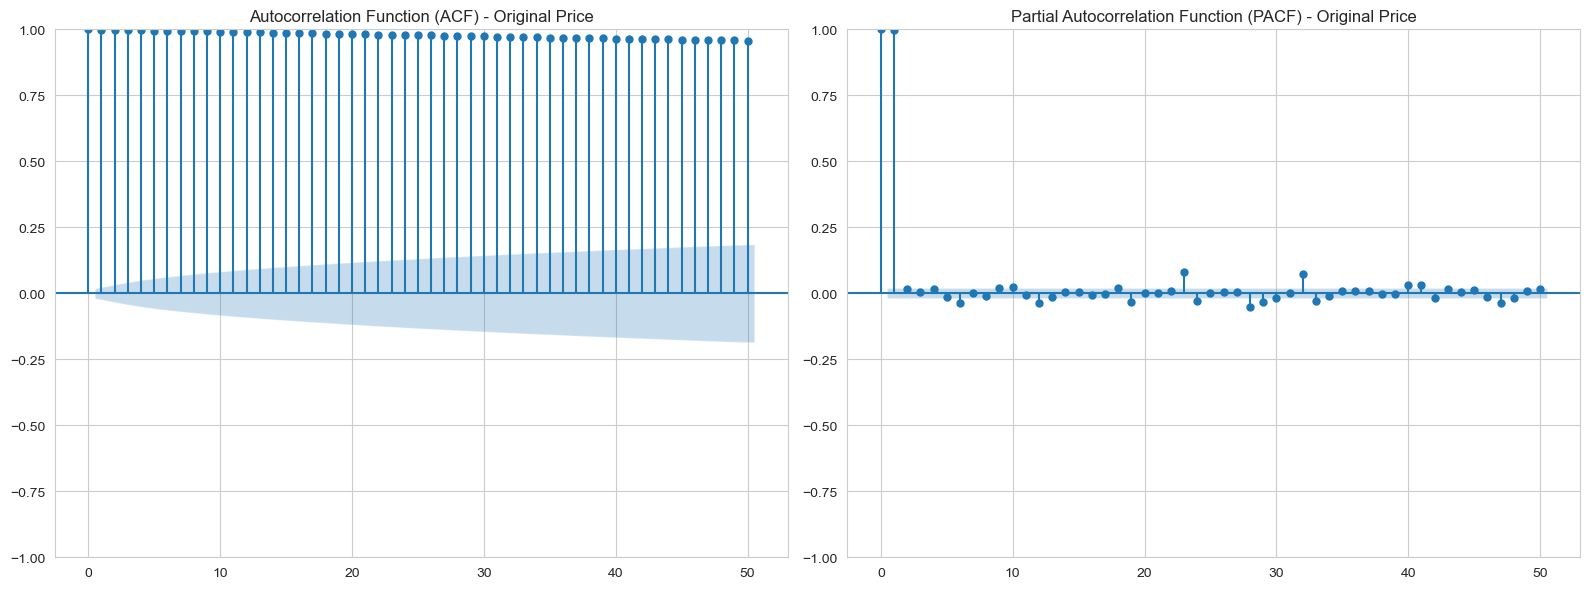

Phân tích biểu đồ ACF và PACF:
- ACF giảm dần rất chậm: Dấu hiệu của chuỗi không dừng (Non-Stationary).
- PACF có gai rất lớn ở lag 1 và sau đó gần như bằng 0: Chỉ có giá hôm qua là có ý nghĩa thống kê trực tiếp nhất.

Để phân tích tốt hơn, chúng ta nên dùng chuỗi đã sai phân (Differenced Series - Return Series):


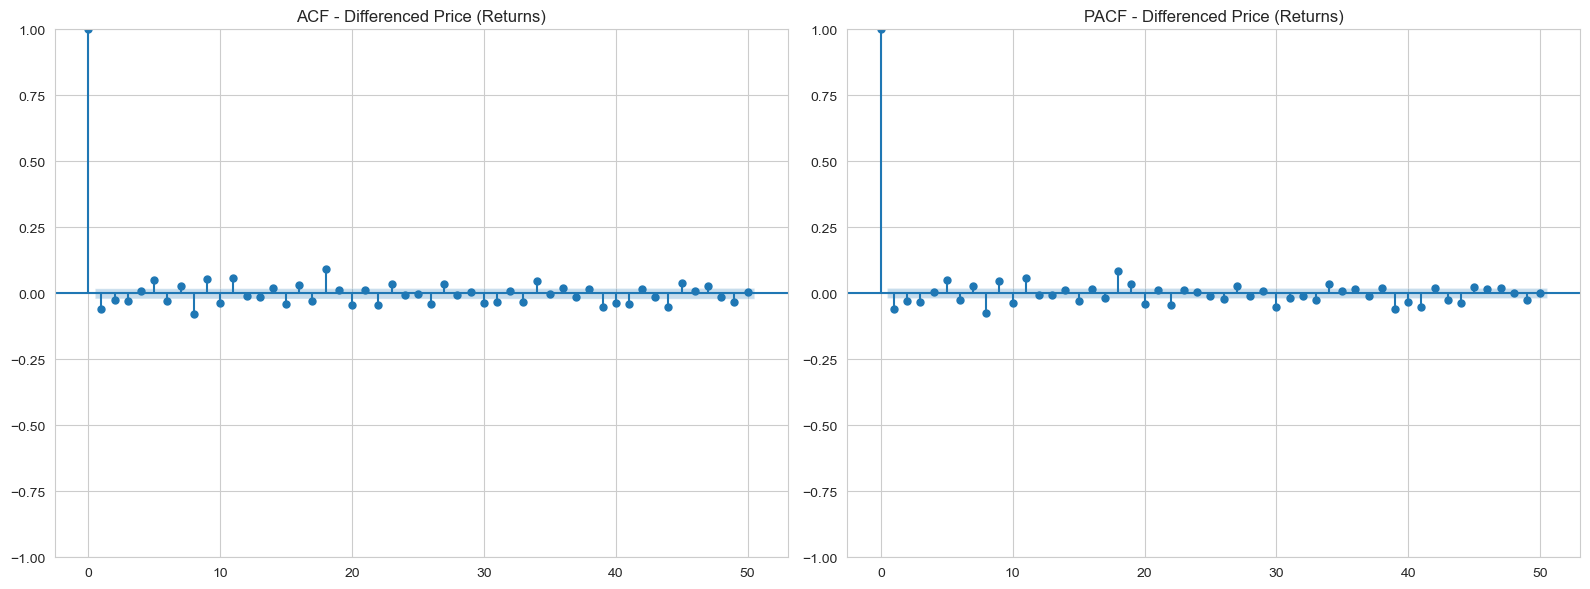

Nhận xét với chuỗi sai phân:
- ACF và PACF tắt rất nhanh sau lag 0.
- Điều này gợi ý rằng biến động giá (Returns) gần như ngẫu nhiên (Random Walk Hypothesis).


In [19]:
# 3. Autocorrelation Function (ACF) và Partial Autocorrelation (PACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot ACF
# ACF cho thấy tương quan bao gồm cả tác động gián tiếp
plot_acf(aapl_features['Close'].dropna(), lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - Original Price')

# Plot PACF
# PACF cho thấy tương quan trực tiếp
plot_pacf(aapl_features['Close'].dropna(), lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - Original Price')

plt.tight_layout()
plt.show()

print("Phân tích biểu đồ ACF và PACF:")
print("- ACF giảm dần rất chậm: Dấu hiệu của chuỗi không dừng (Non-Stationary).")
print("- PACF có gai rất lớn ở lag 1 và sau đó gần như bằng 0: Chỉ có giá hôm qua là có ý nghĩa thống kê trực tiếp nhất.")

print("\nĐể phân tích tốt hơn, chúng ta nên dùng chuỗi đã sai phân (Differenced Series - Return Series):")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Sử dụng Diff_Close (đã tính ở phần 5)
plot_acf(aapl_features['Diff_Close'].dropna(), lags=50, ax=axes[0], title='ACF - Differenced Price (Returns)')
plot_pacf(aapl_features['Diff_Close'].dropna(), lags=50, ax=axes[1], title='PACF - Differenced Price (Returns)')
plt.tight_layout()
plt.show()

print("Nhận xét với chuỗi sai phân:")
print("- ACF và PACF tắt rất nhanh sau lag 0.")
print("- Điều này gợi ý rằng biến động giá (Returns) gần như ngẫu nhiên (Random Walk Hypothesis).")


---

# 8. Tổng kết và Bài tập mở rộng

### Tổng kết
Chúng ta đã hoàn thành quy trình xử lý dữ liệu thời gian cơ bản:
1. **Parsing**: Chuyển đổi string sang datetime, set index.
2. **Handling Gaps**: Xử lý dữ liệu bị thiếu trong chuỗi thời gian.
3. **Feature Extraction**: Tạo ra các biến time components, cyclical features.
4. **Resampling**: Thay đổi khung thời gian (Daily -> Monthly).
5. **Lag & Autocorrelation**: Khai thác mối quan hệ quá khứ - hiện tại.

### Bài tập mở rộng (Optional)
Các bạn có thể thử áp dụng quy trình trên cho 2 mã cổ phiếu còn lại: `MSFT` và `GOOG`. 
1. So sánh biến động giá (`Diff_Close`) của 3 công ty.
2. Tính correlation giữa giá của AAPL và MSFT (xem chúng có cùng tăng giảm không).
3. Resample dữ liệu theo Quý (Quarterly) và vẽ biểu đồ so sánh doanh số (Volume) của 3 công ty.


---

# 9. Phần mở rộng: Generalization & Comparison

Trong phần này, chúng ta sẽ thực hiện các yêu cầu mở rộng:
1. Xây dựng hàm preprocessing tổng quát.
2. Áp dụng cho MSFT và GOOG.
3. So sánh biến động giá và khối lượng giao dịch giữa các công ty.


In [20]:
# 1. Xây dựng hàm preprocessing tổng quát
def preprocess_stock_data(df, ticker_name):
    """
    Hàm thực hiện toàn bộ quy trình tiền xử lý cho một mã cổ phiếu
    """
    print(f"\n{'='*20} Processing {ticker_name} {'='*20}")
    
    # 1. Parsing Date
    df_clean = df.copy()
    if 'Date' in df_clean.columns:
        df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce') # pandas tự detect format
        df_clean = df_clean.dropna(subset=['Date'])
        df_clean = df_clean.sort_values('Date').set_index('Date')
    
    # Check duplicate index
    if df_clean.index.duplicated().any():
        print(f"- Warning: Found duplicate index in {ticker_name}. Keeping first.")
        df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    
    # 2. Extract Components
    df_clean['Year'] = df_clean.index.year
    df_clean['Month'] = df_clean.index.month
    df_clean['Day'] = df_clean.index.day
    df_clean['DayOfWeek'] = df_clean.index.dayofweek
    
    # 3. Handle Gaps (Linear Interpolation cho Close Price nếu cần)
    # Ở đây ta giữ nguyên gaps nhưng tạo bản full index để check
    full_idx = pd.date_range(start=df_clean.index.min(), end=df_clean.index.max(), freq='D')
    missing_cnt = len(full_idx) - len(df_clean)
    print(f"- Time Range: {df_clean.index.min().date()} to {df_clean.index.max().date()}")
    print(f"- Total Days: {len(full_idx)}")
    print(f"- Missing Days: {missing_cnt} ({missing_cnt/len(full_idx)*100:.1f}%)")
    
    # 4. Feature Extraction & Stationarity
    # Return / Differenced Close
    df_clean['Diff_Close'] = df_clean['Close'].diff()
    df_clean['Log_Return'] = np.log(df_clean['Close'] / df_clean['Close'].shift(1))
    
    # Cyclical Features
    df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
    df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)
    
    # Indicator Features (Requirements)
    df_clean['IsWeekend'] = df_clean['DayOfWeek'].isin([5, 6]).astype(int)
    
    # 5. Rolling Features
    df_clean['SMA_20'] = df_clean['Close'].rolling(window=20).mean()
    df_clean['SMA_50'] = df_clean['Close'].rolling(window=50).mean()
    df_clean['Rol_Std_20'] = df_clean['Close'].rolling(window=20).std()
    
    print(f"- Completed preprocessing for {ticker_name}. Shape: {df_clean.shape}")
    return df_clean

# Áp dụng cho MSFT và GOOG (tsla_raw thực chất là GOOG)
msft_processed = preprocess_stock_data(msft_raw, "MSFT")
goog_processed = preprocess_stock_data(tsla_raw, "GOOG")
aapl_processed = preprocess_stock_data(aapl_raw, "AAPL") # Process lại AAPL để đồng bộ


==================== Processing MSFT ====================
- Time Range: 1986-03-13 to 2022-12-12
- Total Days: 13424
- Missing Days: 4160 (31.0%)
- Completed preprocessing for MSFT. Shape: (9264, 18)

==================== Processing GOOG ====================
- Time Range: 2004-08-19 to 2022-12-12
- Total Days: 6690
- Missing Days: 2078 (31.1%)
- Completed preprocessing for GOOG. Shape: (4612, 18)

==================== Processing AAPL ====================
- Time Range: 1980-12-12 to 2022-12-12
- Total Days: 15341
- Missing Days: 11162 (72.8%)
- Completed preprocessing for AAPL. Shape: (4179, 18)


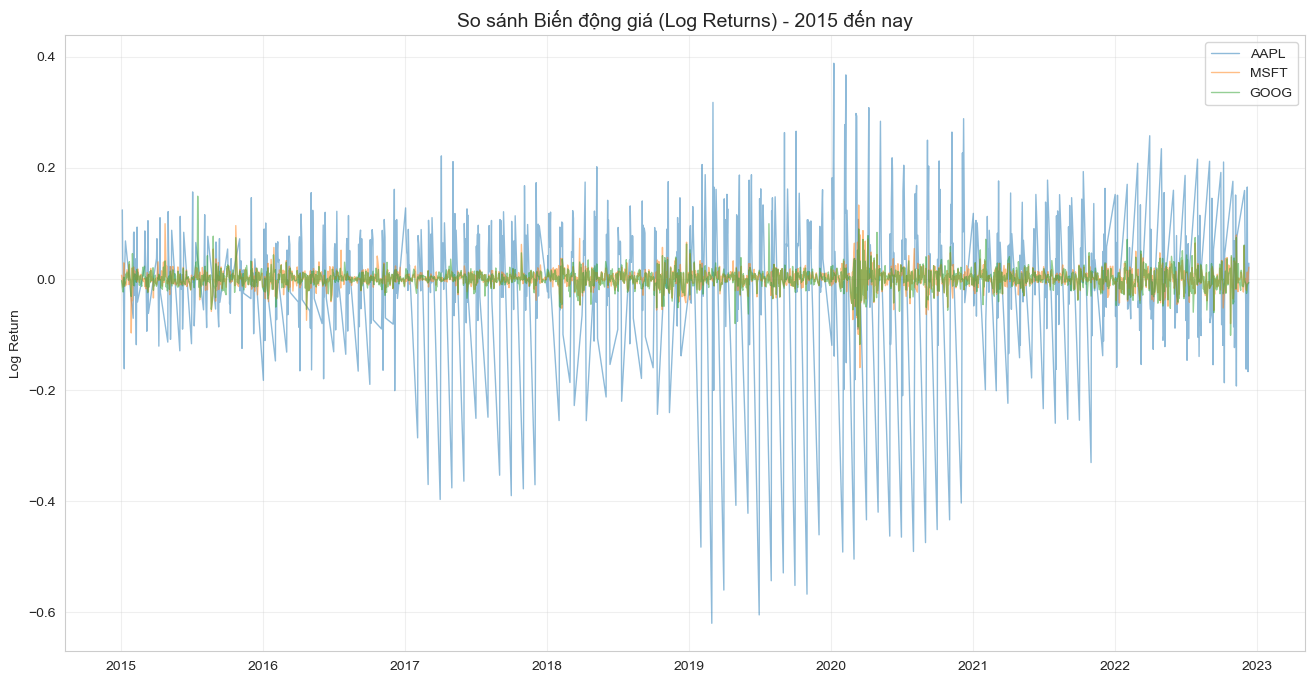


So sánh độ biến động (Rủi ro):


,Stock,Daily Volatility (Std)
0,AAPL,0.219265
1,MSFT,0.021432
2,GOOG,0.019260


In [21]:
# 2. So sánh biến động giá (Volatility Analysis)
# Chúng ta sử dụng Log Returns hoặc Diff_Close để so sánh
plt.figure(figsize=(16, 8))

# Lấy dữ liệu chung từ năm 2015 đến nay để dễ quan sát
start_date = '2015-01-01'

plt.plot(aapl_processed.loc[start_date:].index, aapl_processed.loc[start_date:]['Log_Return'], 
         label='AAPL', alpha=0.5, linewidth=1)
plt.plot(msft_processed.loc[start_date:].index, msft_processed.loc[start_date:]['Log_Return'], 
         label='MSFT', alpha=0.5, linewidth=1)
plt.plot(goog_processed.loc[start_date:].index, goog_processed.loc[start_date:]['Log_Return'], 
         label='GOOG', alpha=0.5, linewidth=1)

plt.title('So sánh Biến động giá (Log Returns) - 2015 đến nay', fontsize=14)
plt.ylabel('Log Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Tính độ lệch chuẩn (Standard Deviation) làm thước đo rủi ro
risks = pd.DataFrame({
    'Stock': ['AAPL', 'MSFT', 'GOOG'],
    'Daily Volatility (Std)': [
        aapl_processed['Log_Return'].std(),
        msft_processed['Log_Return'].std(),
        goog_processed['Log_Return'].std()
    ]
})
print("\nSo sánh độ biến động (Rủi ro):")
display(risks.sort_values('Daily Volatility (Std)', ascending=False))


Ma trận tương quan giá đóng cửa (Close Price Correlation):


,AAPL,MSFT,GOOG
AAPL,1.000000,0.963373,0.953177
MSFT,0.963373,1.000000,0.979465
GOOG,0.953177,0.979465,1.000000


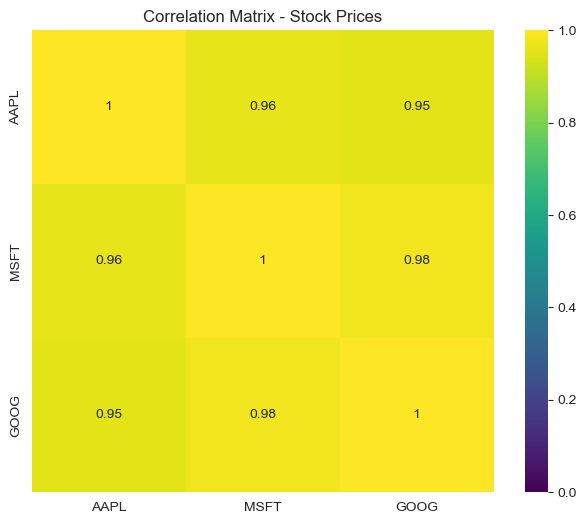


Nhận xét:
- Các cổ phiếu công nghệ này thường có tương quan dương rất mạnh với nhau.
- Khi thị trường chung (Sector Tech) tăng, các mã này thường cùng tăng.


In [22]:
# 3. Phân tích Tương quan (Correlation Analysis)
# Tạo DataFrame chứa giá Close của cả 3 mã
closing_prices = pd.DataFrame({
    'AAPL': aapl_processed['Close'],
    'MSFT': msft_processed['Close'],
    'GOOG': goog_processed['Close']
}).dropna()

# Tính ma trận tương quan
corr_matrix = closing_prices.corr()

print("Ma trận tương quan giá đóng cửa (Close Price Correlation):")
display(corr_matrix)

# Visualization Correlation
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', vmin=0, vmax=1, square=True)
plt.title('Correlation Matrix - Stock Prices')
plt.show()

print("\nNhận xét:")
print("- Các cổ phiếu công nghệ này thường có tương quan dương rất mạnh với nhau.")
print("- Khi thị trường chung (Sector Tech) tăng, các mã này thường cùng tăng.")


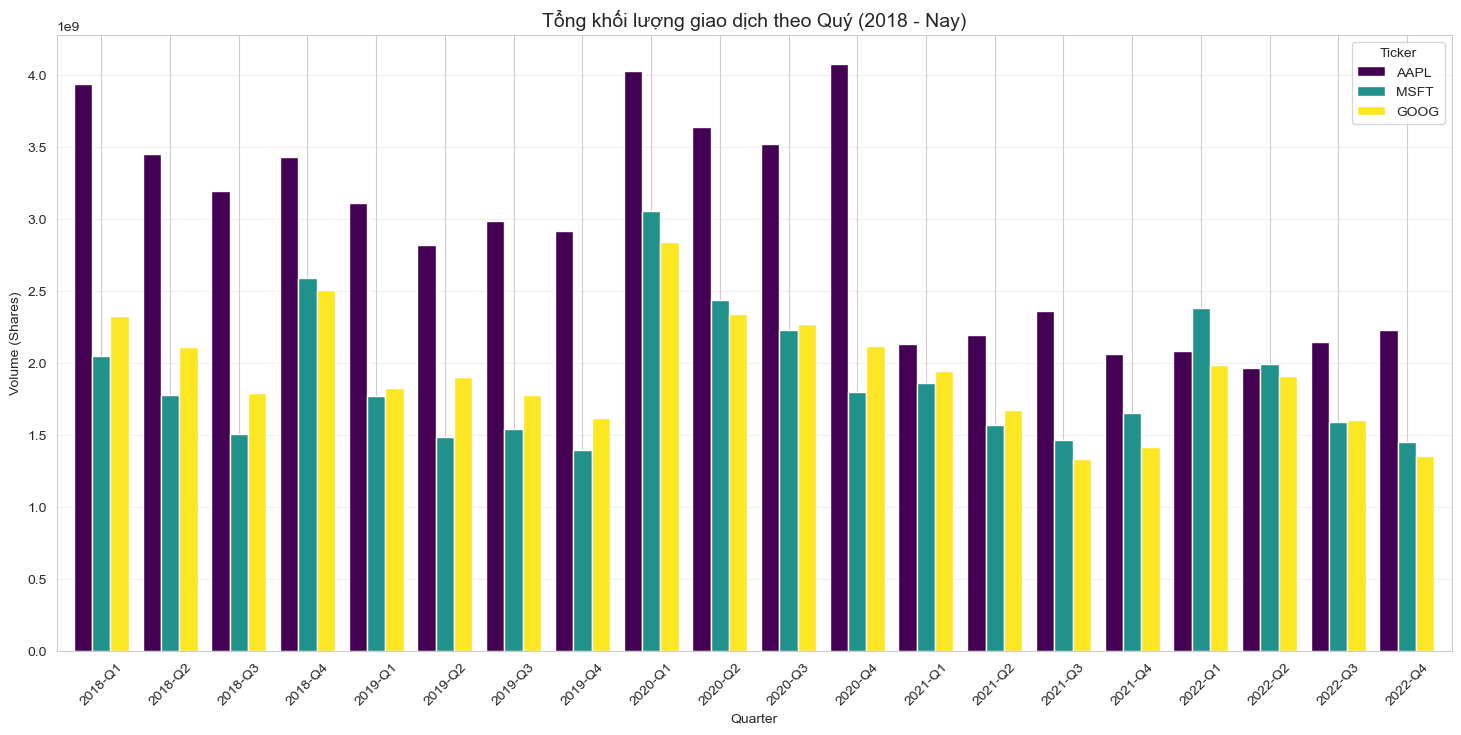

Nhận xét:
- AAPL thường có khối lượng giao dịch (tính bằng số cổ phiếu) cao hơn vượt trội so với MSFT và GOOG.
- Lưu ý: Để so sánh chính xác hơn về giá trị giao dịch, cần nhân Volume với Price (Dollar Volume).


In [23]:
# 4. Resample theo Quý và So sánh Volume
# Resample Quarterly
aapl_q = aapl_processed.resample('Q')['Volume'].sum()
msft_q = msft_processed.resample('Q')['Volume'].sum()
goog_q = goog_processed.resample('Q')['Volume'].sum()

# Combine into DataFrame
volume_q = pd.DataFrame({
    'AAPL': aapl_q,
    'MSFT': msft_q,
    'GOOG': goog_q
})

# Lấy dữ liệu 5 năm gần nhất
volume_recent = volume_q.loc['2018-01-01':]

# Plot Grouped Bar Chart
ax = volume_recent.plot(kind='bar', width=0.8, figsize=(18, 8), colormap='viridis')
plt.title('Tổng khối lượng giao dịch theo Quý (2018 - Nay)', fontsize=14)
plt.ylabel('Volume (Shares)')
plt.xlabel('Quarter')

# Format x-axis labels to show Year-Quarter cleanly
# strftime không hỗ trợ %q (quarter), nên chúng ta dùng f-string
new_labels = [f"{d.year}-Q{d.quarter}" for d in volume_recent.index]
ax.set_xticklabels(new_labels, rotation=45)

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Ticker')
plt.show()

print("Nhận xét:")
print("- AAPL thường có khối lượng giao dịch (tính bằng số cổ phiếu) cao hơn vượt trội so với MSFT và GOOG.")
print("- Lưu ý: Để so sánh chính xác hơn về giá trị giao dịch, cần nhân Volume với Price (Dollar Volume).")

---
# HẾT - End of Notebook
